In [1]:
import numpy

from src import *
import matplotlib.pyplot as plt

logger = logging.getLogger("global_logger")
logging.basicConfig(filename='../gap_handler_test.log', format='%(levelname)s: %(message)s', encoding='utf-8', filemode='w', level=logging.DEBUG)
logger.info("NEW START")
data = get_combined_data()
replay_settings = SimulationParameters("default")
replay_settings.load_max_velocity()
replay_settings.save_to_file()
#action_names = ["kick", "sidestep", "turn", "walk", "standup_back", "standup_front"]
#indices = [0,1,2,3,4]
simulator = SimulatorHandler()
simulator.num_instances = 5
simulator.show_ui = False
gap_handler = simulator.simulation_gap(settings=replay_settings, data=data)
gap_handler_visualizer = GapHandlerVisualizer(gap_handler)

In [2]:
# define which logs to use for testing
action_name = "walk_front"
recording_date = "260108"
log_index = 4
joint_name = "y_gyro"
start_frame = 0
end_frame = -1


# extraction:   get_pos_extraction, get_vel_extraction, get_acc_extraction
# replay:       get_pos_replay, get_vel_replay, get_acc_replay
# gaps:         get_pos_gap, get_vel_gap, get_acc_gap, get_total_gap
f0 = lambda gap_object : SimulationGapData.get_vel_replay(gap_object, [joint_name], start_frame, end_frame)
f0_name = "pos_gap"

# get_pos_gap_avg_for_joints, get_vel_gap_avg_for_joints get_acc_gap_avg_for_joints, get_total_gap_avg_for_joints
f1 = lambda gap_object : SimulationGapData.get_total_gap_for_sensors(gap_object, None, start_frame, end_frame)
f1_name = "get_total_gap_avg_for_joints"

# get_pos_gap_avg_for_frames, get_vel_gap_avg_for_frames get_acc_gap_avg_for_frames, get_total_gap_avg_for_frames
f2 = lambda gap_object : SimulationGapData.get_total_gap_for_frames(gap_object, None, start_frame, end_frame)
f2_name = "get_total_gap_avg_for_frames"

In [3]:
all_of_action = gap_handler.get_all(action_name)
gaps = [(gap_data, numpy.nanmin(gap_data.get_vel_replay()["y_gyro"][0:500])) for gap_data in all_of_action]
avg = numpy.average([tup[1] for tup in gaps])
print("avg: " + str(avg))
for gap_data, gap in gaps:
    if gap <avg:
        print(gap_data.identifier + ": " + str(gap))




avg: -36.19393982352941
default;walk_front;260528_0;1: -42.612065
default;walk_front;260528_0;4: -43.998669
default;walk_front;260528_0;5: -38.313335
default;walk_front;260528_0;9: -36.955822999999995
default;walk_front;260529_0;1: -39.428401
default;walk_front;260529_0;2: -38.086799
default;walk_front;260528_1;0: -37.480989
default;walk_front;260528_1;1: -45.150736
default;walk_front;260529_1;0: -36.463712


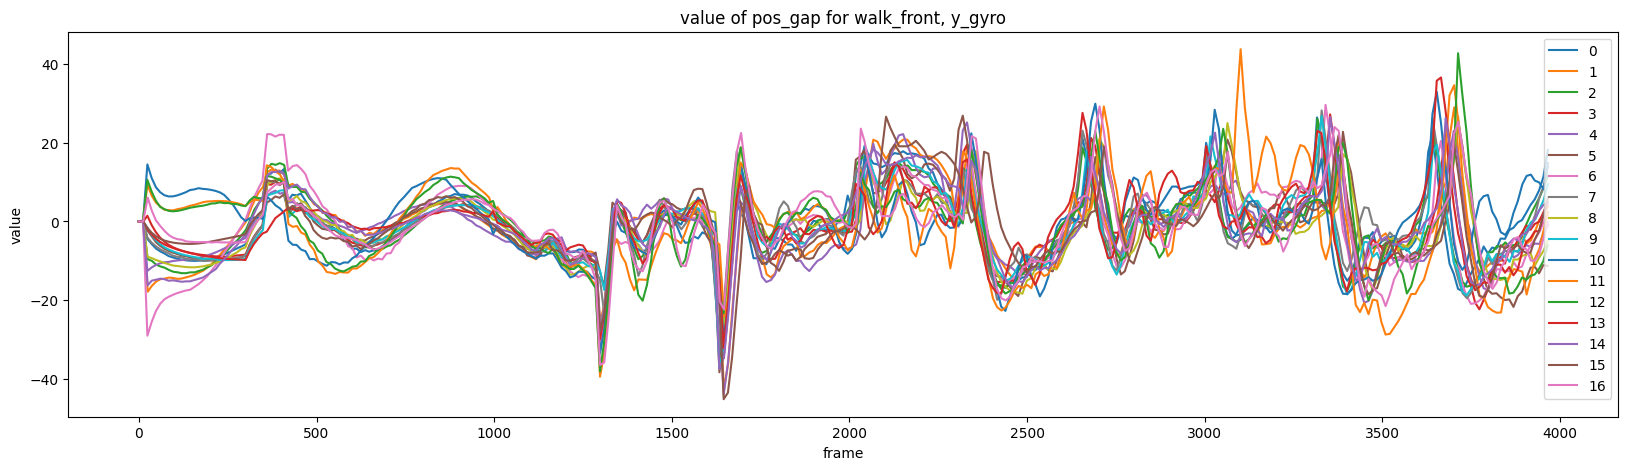

In [4]:
gap_handler_visualizer.plt_all_for_action_joint(action_name, joint_name, f0_name, f0, start_frame, end_frame)

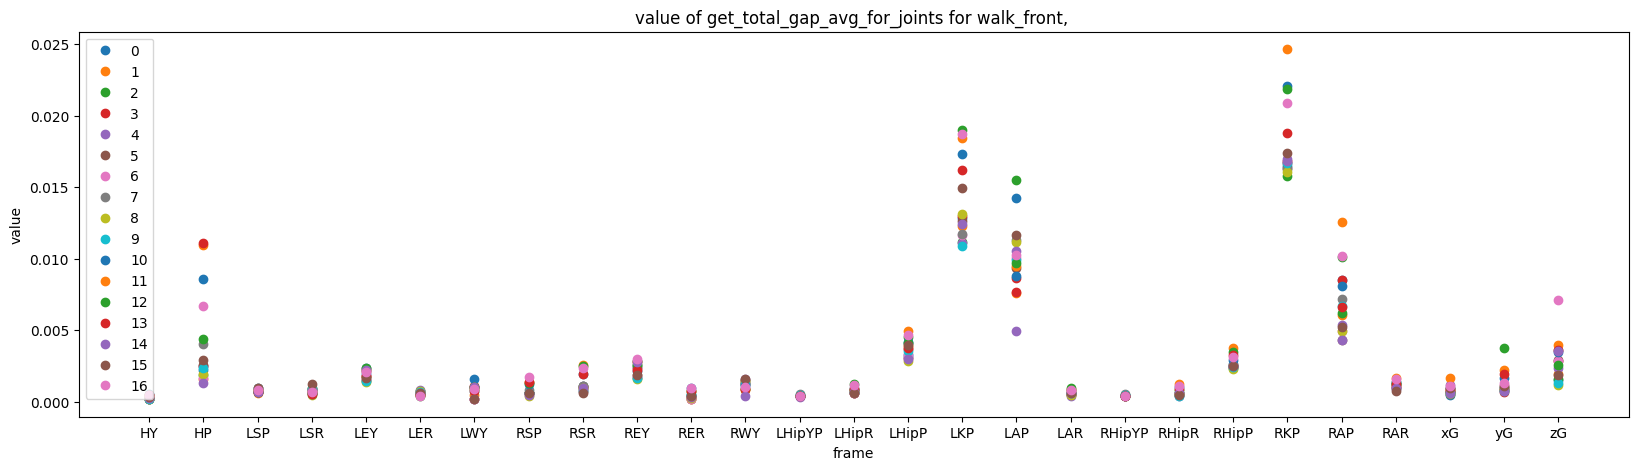

In [5]:
gap_handler_visualizer.plt_all_gap_avg_for_joints(action_name, f1_name, f1)

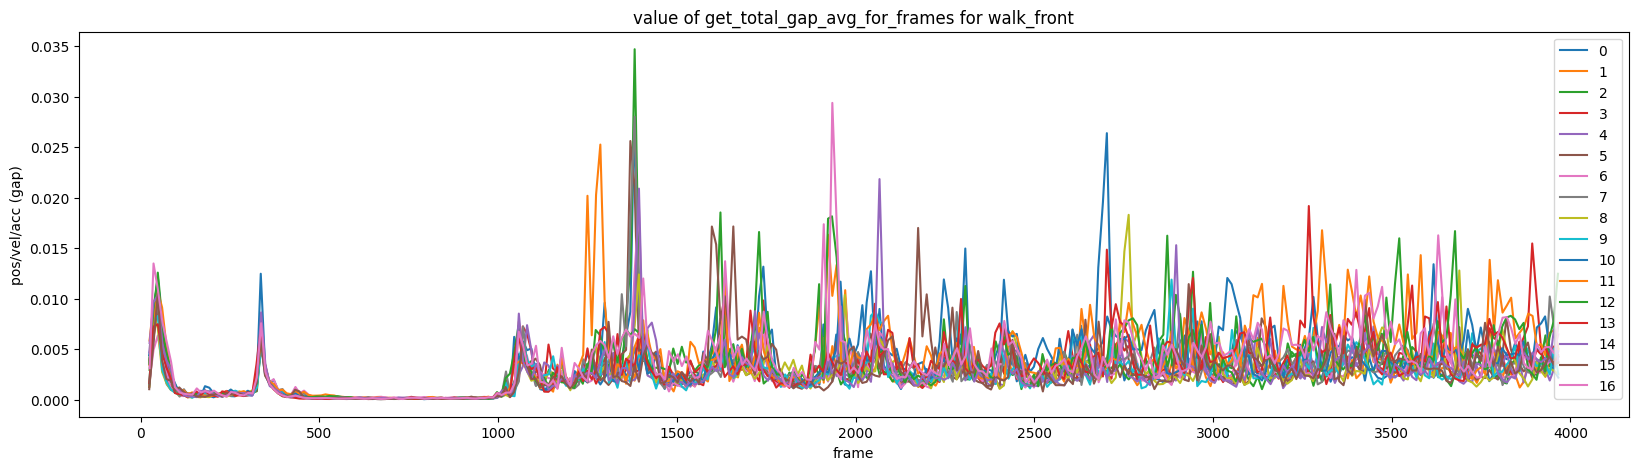

In [6]:
gap_handler_visualizer.plt_all_gap_avg_for_frames(action_name, f2_name, f2,start_frame, end_frame)

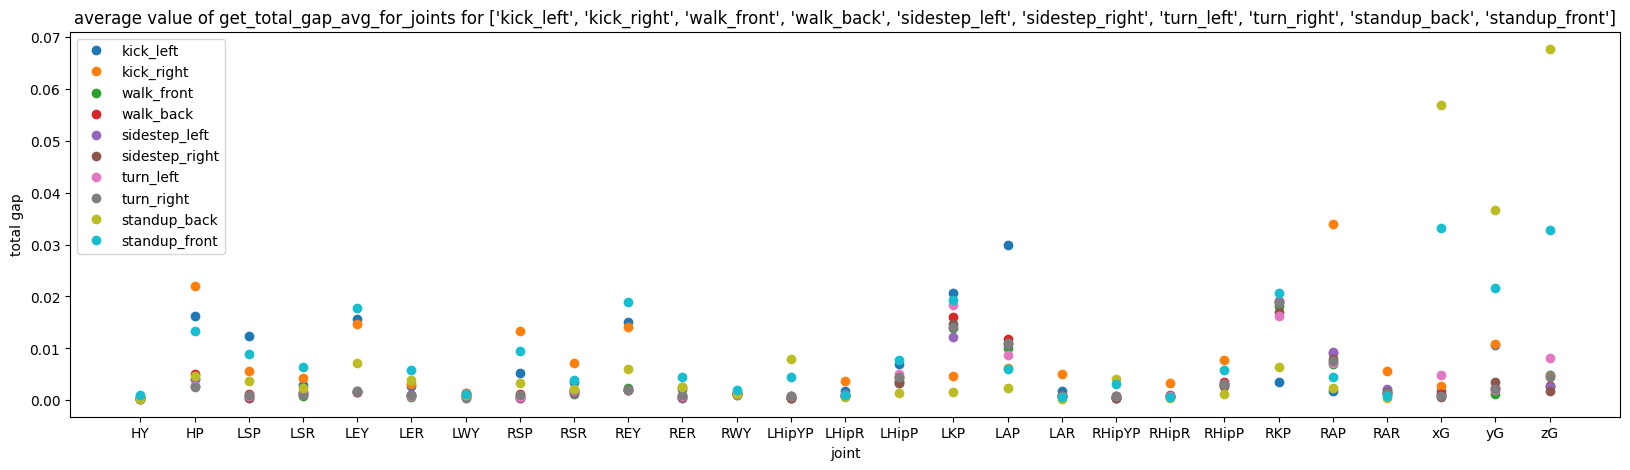

In [7]:
gap_handler_visualizer.plt_gap_avg_for_joints(f1_name, f1)

C:\Users\felix\PycharmProjects\Thesis\src\Utils\SimulationGapHandler.py:120: RuntimeWarning: Mean of empty slice
  result[action_name] = [np.nanmean(np.array(group, dtype=float)) for group in zip_longest(*partial_results, fillvalue=np.nan)]


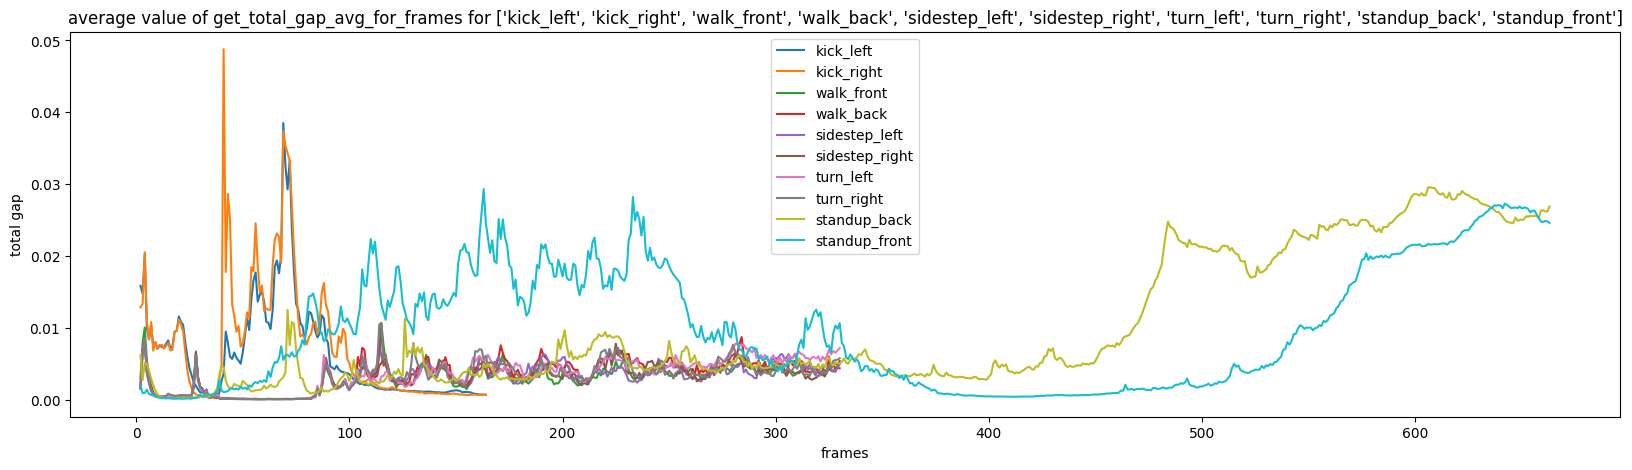

In [8]:
gap_handler_visualizer.plt_gap_avg_for_frames(f2_name, f2)

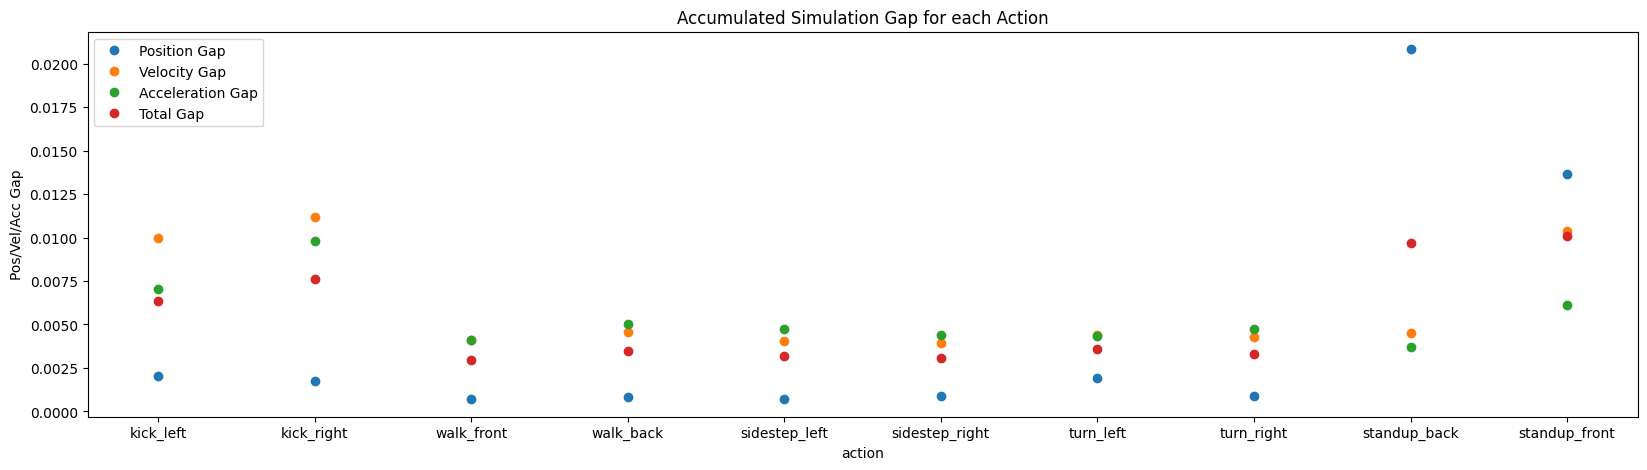

In [9]:
gap_handler_visualizer.plt_gap_avg(start_frame, end_frame)

In [10]:
print(gap_handler.get_optimization_target(lambda x : SimulationGapData.get_pos_gap_avg(x, None, start_frame, end_frame)))
print(gap_handler.get_optimization_target(lambda x : SimulationGapData.get_vel_gap_avg(x, None, start_frame, end_frame)))
print(gap_handler.get_optimization_target(lambda x : SimulationGapData.get_acc_gap_avg(x, None, start_frame, end_frame)))
print(gap_handler.get_optimization_target(lambda x : SimulationGapData.get_total_gap_avg(x, None, start_frame, end_frame)))

0.005619798614850676
0.006018768815647198
0.005207021714887025
0.005627389081850854


gap_handler_visualizer